# 🎯 Extracción Refinada de Facturas

El objetivo de este notebook es utilizar un modelo avanzado **(Donut de Hugging Face)** para extraer de forma estructurada los siguientes datos clave de cualquier factura:
1. **Fecha**
2. **Total gastado/ingresado**
3. **Lista de artículos** (Concepto, Unidades)

In [1]:
# 1. Importación de librerías
import os
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from transformers import DonutProcessor, VisionEncoderDecoderModel
import re

c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Descargar una factura de prueba
os.makedirs('sample_invoices', exist_ok=True)
test_url = "https://raw.githubusercontent.com/mouadhamri/invoice_dataset/main/invoice_dataset_model_1/images/FACTU2015020048.jpg"
test_img_path = "sample_invoices/invoice_refined_test.jpg"

if not os.path.exists(test_img_path):
    response = requests.get(test_url, stream=True)
    if response.status_code == 200:
        with open(test_img_path, 'wb') as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)
        print("Imagen descargada con éxito.")
    else:
        print("No se pudo descargar la imagen de prueba.")

Imagen descargada con éxito.


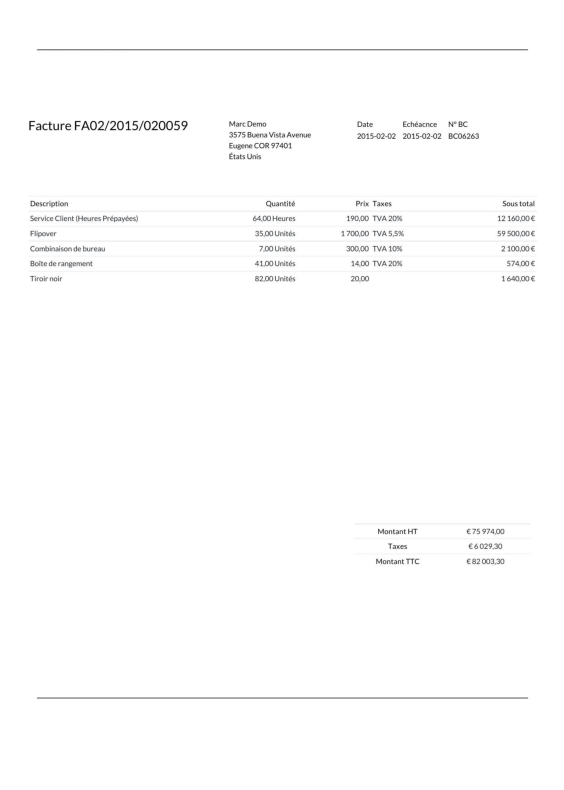

In [3]:
# Mostrar la imagen de prueba
img = Image.open(test_img_path).convert('RGB')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
# 3. Cargar el Modelo Donut (Fine-tuned para Recibos y Facturas)
# CORD-v2 es un dataset de recibos, muy útil para este caso.
print("Cargando modelo Donut...")
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base-finetuned-cord-v2")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base-finetuned-cord-v2")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Modelo cargado en {device}")

Cargando modelo Donut...


The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 484/484 [00:00<00:00, 21170.76it/s]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Modelo cargado en cpu


In [5]:
# 4. Función de Inferencia
def extract_invoice_data_raw(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values
    
    task_prompt = "<s_cord-v2>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids
    
    outputs = model.generate(
        pixel_values.to(device),
        decoder_input_ids=decoder_input_ids.to(device),
        max_length=model.decoder.config.max_position_embeddings,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
    
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()  # remove first task start token
    
    return processor.token2json(sequence)

### 🛠 Procesamiento y Refinamiento del JSON
El modelo Donut CORD-v2 nos dará un JSON crudo. Vamos a escribir una función robusta para extraer únicamente:
1. La fecha (`fecha`)
2. El total (`total_gastado`)
3. La lista de compras (`conceptos`: `[(nombre, unidades)]`)

In [6]:
def parse_refined_invoice_data(raw_json):
    fecha = "No encontrada"
    total_gastado = "0.00"
    lista_conceptos = []
    
    # 1. Extraer Fecha (Suele estar en store_info -> date, o valid_date, receipt_date)
    if isinstance(raw_json.get("store_info"), dict):
        if "date" in raw_json["store_info"]:
            fecha = raw_json["store_info"]["date"]
    if isinstance(raw_json.get("receipt_date"), str) and fecha == "No encontrada":
        fecha = raw_json["receipt_date"]
    if isinstance(raw_json.get("valid_date"), str) and fecha == "No encontrada":
        fecha = raw_json["valid_date"]
        
    # 2. Extraer Total
    if isinstance(raw_json.get("total"), dict):
        if "total_price" in raw_json["total"]:
            total_gastado = raw_json["total"]["total_price"]
        elif "cashprice" in raw_json["total"]:
            total_gastado = raw_json["total"]["cashprice"]
        elif "creditcardprice" in raw_json["total"]:
            total_gastado = raw_json["total"]["creditcardprice"]
    
    # 3. Extraer Lista de Items (Concepto, Unidades)
    # Los items suelen venir en 'menu', que es una lista de diccionarios.
    menu_items = raw_json.get("menu", [])
    if isinstance(menu_items, dict):
        menu_items = [menu_items] # a veces Donut devuelve un solo dict si solo hay un item
        
    for item in menu_items:
        if isinstance(item, dict):
            concepto = item.get("nm", "Desconocido")
            unidades = item.get("cnt", "1")  # Si no especifica cantidad, asumimos 1
            lista_conceptos.append((concepto, unidades))
            
    return {
        "fecha": fecha,
        "total_gastado": total_gastado,
        "articulos": lista_conceptos
    }

In [7]:
# 5. Prueba Final
print("\n--- ANALIZANDO FACTURA ---\n")
raw_data = extract_invoice_data_raw(test_img_path)
datos_refinados = parse_refined_invoice_data(raw_data)

print("=== DATOS EXTRAÍDOS ===")
print(f"📅 Fecha: {datos_refinados['fecha']}")
print(f"💰 Total: {datos_refinados['total_gastado']}")
print("🛒 Conceptos:")
for concepto, unidades in datos_refinados['articulos']:
    print(f"   - {unidades}x {concepto}")

print("\n--- JSON Crudo del Modelo (Para depuración) ---")
import json
print(json.dumps(raw_data, indent=2, ensure_ascii=False))


--- ANALIZANDO FACTURA ---

=== DATOS EXTRAÍDOS ===
📅 Fecha: No encontrada
💰 Total: 75,974.00
🛒 Conceptos:
   - Datex Facture FA02/2015/020059
   - 1x Eugene COR 9701

--- JSON Crudo del Modelo (Para depuración) ---
{
  "menu": [
    {
      "nm": "Facture FA02/2015/020059",
      "cnt": "Date",
      "price": "N\"BC"
    },
    {
      "nm": "Eugene COR 9701",
      "unitprice": "2015-02-02",
      "price": "2015-02"
    }
  ],
  "sub_total": {
    "subtotal_price": "300.00",
    "tax_price": "5,400"
  },
  "total": {
    "total_price": "75,974.00",
    "cashprice": "6029.30",
    "changeprice": "682003.30"
  }
}
